# Plot Zero-Variance extrapolation - 1D chain L = 20

In [1]:
import glob
import os
import sys

In [2]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.MC_extrapol import run_monte_carlo_extrapolation
from src.plot.plotlib import *

In [3]:
verbose = True

In [4]:
# Settings
L = 20                                              # Length of the Markov chain
N_sim = 1000000                                     # Number of Monte Carlo simulations

## Alpha optimization

In [5]:
dossiers = glob.glob("../../datas/datas_alpha_iter_*") 

Loading and processing 4 folders...
✅ Loading complete: 3 simulations processed!
Generating 1000000 synthetic linear regressions...

========== GLOBAL MONTE CARLO RESULTS ==========
Points used for fit       : 6 (3 simulations)
Exact Energy              : -0.44521933
Extrapolated Energy       : -0.44534618 ± 0.00044116
95% Confidence Interval   : [-0.44621966 , -0.44445306]
Absolute Error vs Exact   : 1.27e-04


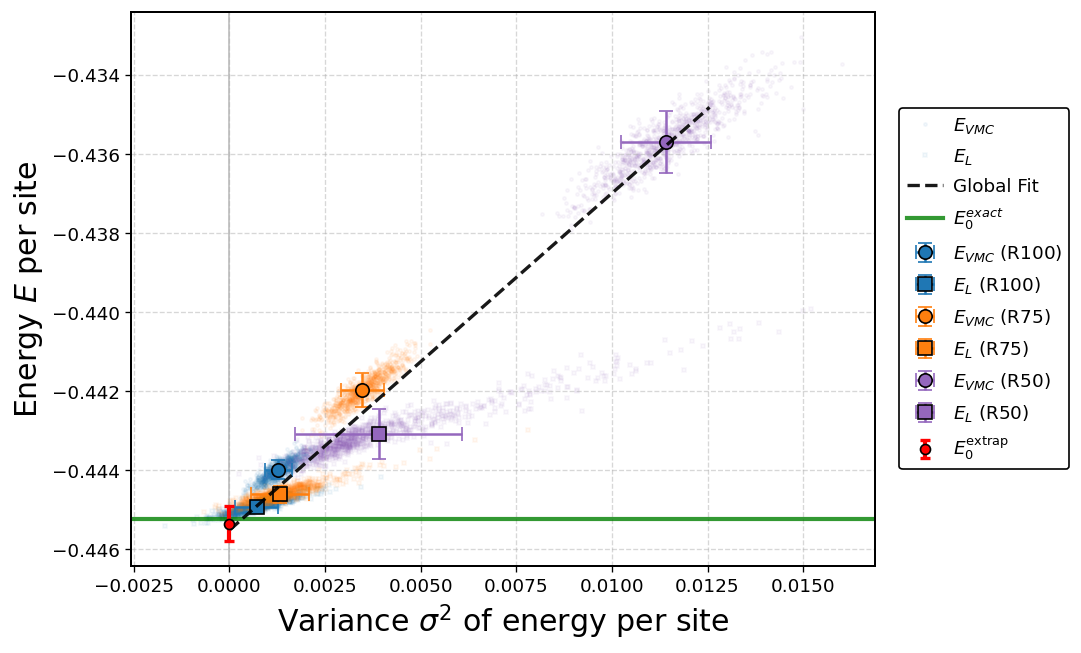

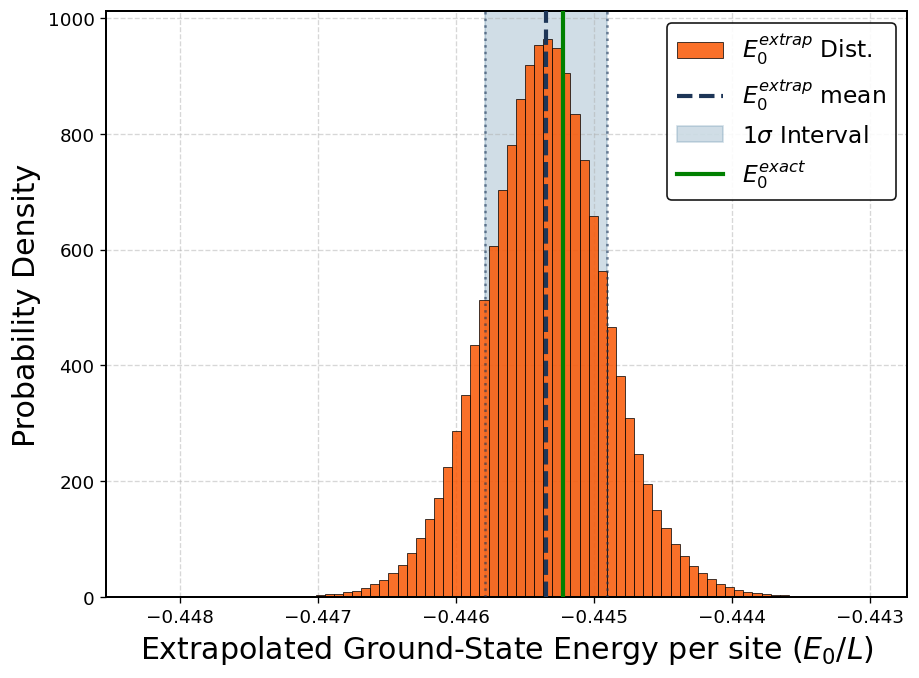

In [6]:
data_dict_AL = load_simulation_data(dossiers, L, verbose=True)
mc_results_AL = run_monte_carlo_extrapolation(data_dict_AL, N_sim, verbose=True)

plot_master_extrapolation(data_dict_AL, mc_results_AL, L, save_dir="../../assets", name="AL_extrapolation")
plot_extrapolation_distribution(data_dict_AL, mc_results_AL, save_dir="../../assets", name="AL_distribution")

In [7]:
df_results = create_results_table(data_dict_AL, L)
print(df_results.to_string(index=False))

 vmc_it  energy VMC  var VMC  sem VMC  energy lanczos  var lanczos  sem lanczos
     50   -0.435682 0.011411 0.000361       -0.443077     0.003899     0.000123
     75   -0.441954 0.003476 0.000110       -0.444607     0.001329     0.000042
    100   -0.443984 0.001277 0.000040       -0.444926     0.000707     0.000022


## Krylov Subspace 

In [8]:
dossiers = glob.glob("../../datas/datas_krylov_iter_*") 

Loading and processing 3 folders...
✅ Loading complete: 3 simulations processed!
Generating 1000000 synthetic linear regressions...

========== GLOBAL MONTE CARLO RESULTS ==========
Points used for fit       : 6 (3 simulations)
Exact Energy              : -0.44521933
Extrapolated Energy       : -0.44541300 ± 0.00037090
95% Confidence Interval   : [-0.44620291 , -0.44474707]
Absolute Error vs Exact   : 1.94e-04


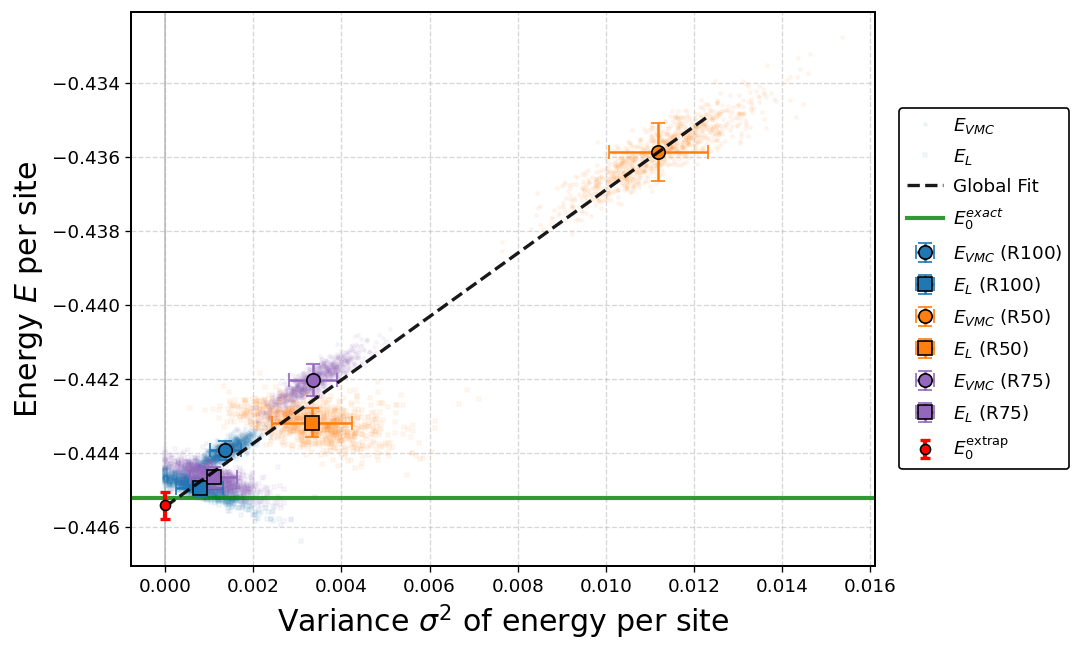

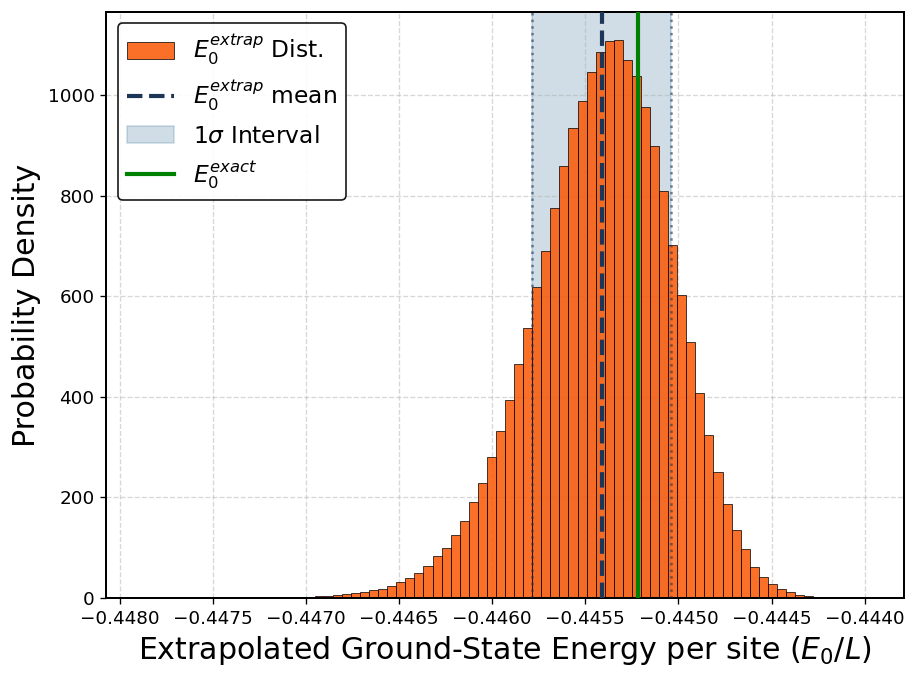

In [9]:
data_dict_KR = load_simulation_data(dossiers, L, verbose=True)
mc_results_KR = run_monte_carlo_extrapolation(data_dict_KR, N_sim, verbose=True)

plot_master_extrapolation(data_dict_KR, mc_results_KR, L, save_dir="../../assets", name="Krylov_extrapolation")
plot_extrapolation_distribution(data_dict_KR, mc_results_KR, save_dir="../../assets", name="Krylov_distribution")

In [10]:
df_results = create_results_table(data_dict_KR, L)
print(df_results.to_string(index=False))

 vmc_it  energy VMC  var VMC  sem VMC  energy lanczos  var lanczos  sem lanczos
     50   -0.435875 0.011191 0.000354       -0.443181     0.003333     0.000105
     75   -0.442038 0.003345 0.000106       -0.444658     0.001102     0.000035
    100   -0.443930 0.001366 0.000043       -0.444937     0.000784     0.000025


## Comparaison 

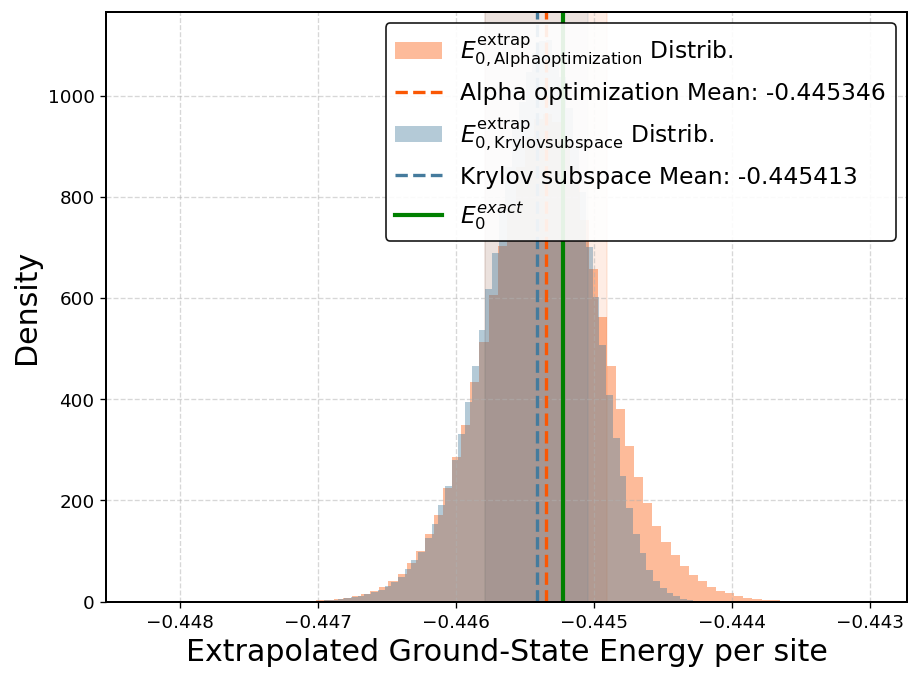

In [12]:
mes_distributions = {
    "Alpha optimization": mc_results_AL,
    "Krylov subspace": mc_results_KR
}

E_exacte = data_dict_AL["exact_gs_energy_per_site"]
plot_multiple_extrapolation_distributions(mes_distributions, E_exacte, save_dir="../../assets")